In [1]:
import pandas as pd
import csv
import krippendorff
import numpy as np


In [2]:
df = pd.read_csv('../Datasets/annotations.csv', delimiter=",", encoding='utf-8')
columns_to_keep = ['tag_tamara', 'tag_katja']
df1 = df[columns_to_keep]
df1


,tag_tamara,tag_katja
0,P_Neutral,P_Neutral
1,N_Neutral,Negative
2,P_Neutral,NaN
3,N_Neutral,N_Neutral
4,N_Neutral,NaN
...,...,...
2595,N_Neutral,N_Neutral
2596,P_Neutral,N_Neutral
2597,Negative,Negative
2598,P_Neutral,P_Neutral


In [3]:
df1 = df1.dropna()
df1

,tag_tamara,tag_katja
0,P_Neutral,P_Neutral
1,N_Neutral,Negative
3,N_Neutral,N_Neutral
5,N_Neutral,Negative
6,N_Neutral,N_Neutral
...,...,...
2595,N_Neutral,N_Neutral
2596,P_Neutral,N_Neutral
2597,Negative,Negative
2598,P_Neutral,P_Neutral


In [4]:
unique_labels = pd.unique(df1[['tag_tamara', 'tag_katja']].values.ravel())

# Create a mapping of labels to consistent numeric codes
label_to_code = {label: idx for idx, label in enumerate(unique_labels)}

# Map the labels to numeric codes for both annotators
df1['tag_tamara_codes'] = df1['tag_tamara'].map(label_to_code)
df1['tag_katja_codes'] = df1['tag_katja'].map(label_to_code)
df1


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_2349/2607418366.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['tag_tamara_codes'] = df1['tag_tamara'].map(label_to_code)
/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_2349/2607418366.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['tag_katja_codes'] = df1['tag_katja'].map(label_to_code)


,tag_tamara,tag_katja,tag_tamara_codes,tag_katja_codes
0,P_Neutral,P_Neutral,0,0
1,N_Neutral,Negative,1,2
3,N_Neutral,N_Neutral,1,1
5,N_Neutral,Negative,1,2
6,N_Neutral,N_Neutral,1,1
...,...,...,...,...
2595,N_Neutral,N_Neutral,1,1
2596,P_Neutral,N_Neutral,0,1
2597,Negative,Negative,2,2
2598,P_Neutral,P_Neutral,0,0


In [5]:
data_array = df1[['tag_tamara_codes', 'tag_katja_codes']].to_numpy().T
alpha = krippendorff.alpha(reliability_data=data_array, level_of_measurement='nominal')
print(f"Krippendorff's alpha (nominal): {alpha}")


Krippendorff's alpha (nominal): 0.5099808584431593


## Checking final tags distribution

Cleaning the dataset

In [6]:
tags = ['final_tag']
df2 = df[tags]
mapping = {
    'Negative': 'Negative',
    'M_Negative': 'Mixed Negative',    
    'N_Neutral': 'Neutral Negative',   
    'P_Neutral': 'Neutral Positive',   
    'M_Positive': 'Mixed Positive',
    'Positive': 'Positive',
    'N_Neutral(S)':'Neutral Negative',
    'Negative(S)':'Negative',
    'N_Neutral (S)':'Neutral Negative',
    'Negative (S)':'Negative',
    'Positive(S)':'Positive',
    'Positive (S)':'Positive',
    'M_Negative(S)': 'Mixed Negative',
    'N_Negative': 'Neutral Negative',
    'Negative. ': 'Negative',
    'P_Neutral(S)': 'Neutral Positive',
    'Postive':'Positive',
    'Negatvie':'Negative'
}

df2['labels'] = df2['final_tag'].map(mapping)
df2

/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_2349/3921669549.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['labels'] = df2['final_tag'].map(mapping)


,final_tag,labels
0,P_Neutral,Neutral Positive
1,Negative,Negative
2,P_Neutral,Neutral Positive
3,N_Neutral(S),Neutral Negative
4,N_Neutral(S),Neutral Negative
...,...,...
2595,N_Neutral,Neutral Negative
2596,P_Neutral,Neutral Positive
2597,Negative,Negative
2598,P_Neutral,Neutral Positive


In [7]:
print(df2[df2.isna().any(axis=1)])

Empty DataFrame
Columns: [final_tag, labels]
Index: []


Checking label percentage distribution

In [8]:
count_labels = df2['labels'].value_counts()
count_labels

labels
Negative            966
Neutral Positive    750
Neutral Negative    660
Positive            138
Mixed Negative       43
Mixed Positive       43
Name: count, dtype: int64

In [9]:
label_percentage = (count_labels / count_labels.sum()) * 100
label_percentage

labels
Negative            37.153846
Neutral Positive    28.846154
Neutral Negative    25.384615
Positive             5.307692
Mixed Negative       1.653846
Mixed Positive       1.653846
Name: count, dtype: float64

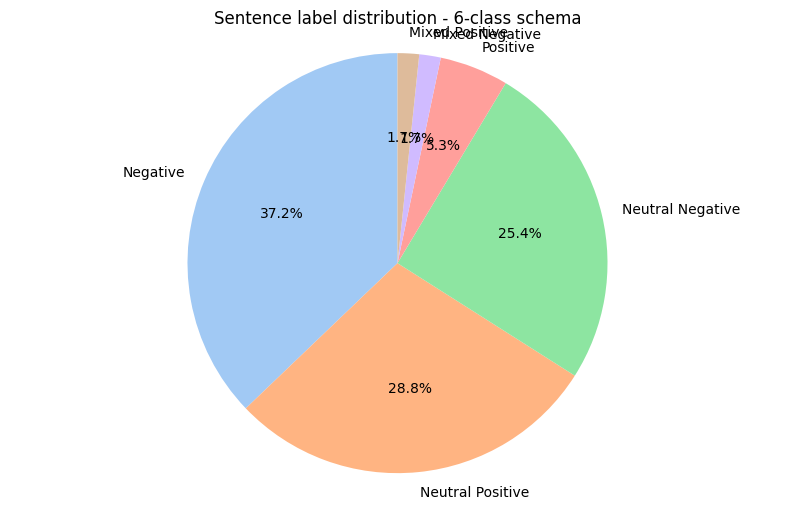

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette('pastel')

plt.figure(figsize=(10,6))
plt.pie(label_percentage, labels=label_percentage.index, colors=palette, autopct='%1.1f%%', startangle=90)
plt.title('Sentence label distribution - 6-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_6class.png', dpi=300)
plt.show()


Checking the 3-class mappings

In [12]:
mapping_sent = {
    'Negative': 'Negative',
    'Mixed Negative': 'Negative',    
    'Neutral Negative': 'Neutral',   
    'Neutral Positive': 'Neutral',   
    'Mixed Positive': 'Positive',
    'Positive': 'Positive'
}

df2['sentiment'] = df2['labels'].map(mapping_sent)
df2

/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_2349/2759916944.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['sentiment'] = df2['labels'].map(mapping_sent)


,final_tag,labels,sentiment
0,P_Neutral,Neutral Positive,Neutral
1,Negative,Negative,Negative
2,P_Neutral,Neutral Positive,Neutral
3,N_Neutral(S),Neutral Negative,Neutral
4,N_Neutral(S),Neutral Negative,Neutral
...,...,...,...
2595,N_Neutral,Neutral Negative,Neutral
2596,P_Neutral,Neutral Positive,Neutral
2597,Negative,Negative,Negative
2598,P_Neutral,Neutral Positive,Neutral


In [13]:
count_sentiment = df2['sentiment'].value_counts()

In [14]:
sentiment_percentage = (count_sentiment / count_sentiment.sum()) *100
sentiment_percentage

sentiment
Neutral     54.230769
Negative    38.807692
Positive     6.961538
Name: count, dtype: float64

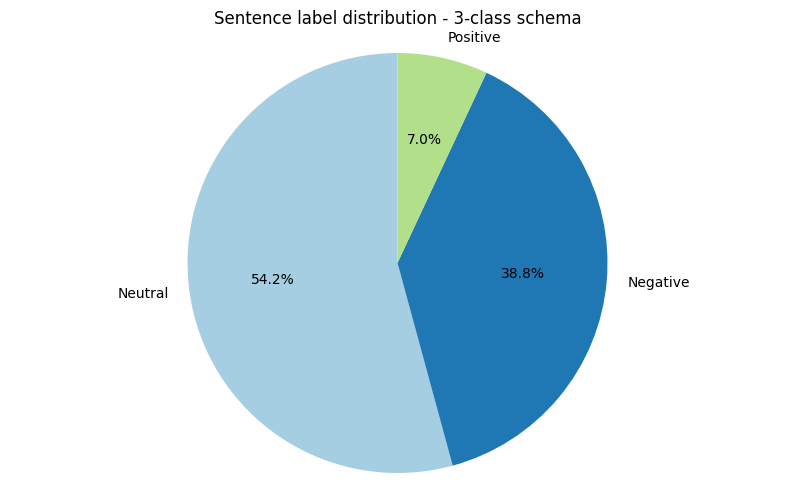

In [16]:
palette2 = sns.color_palette('Paired')
plt.figure(figsize=(10, 6))
plt.pie(sentiment_percentage, labels=sentiment_percentage.index, colors=palette2, startangle=90, autopct='%1.1f%%')
plt.title('Sentence label distribution - 3-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_3class.png', dpi=300)
plt.show()